# Derivatives of models

"What is the derivative of my model?" is four different questions, and discopt answers
all four. This notebook walks through them in order of how much machinery each needs,
and ends at the one call that covers the lot.

| You want | The question | Needs a solve? | Call |
|---|---|---|---|
| $\partial e/\partial x$ symbolically | slope of an expression | no | `discopt.bilevel.diff` |
| $\partial e/\partial x$, $\partial e/\partial p$ numerically | gradients for your own pipeline | no | `discopt.parametric.compile_expression` |
| $\mathrm{d}(\mathrm{obj}^*)/\mathrm{d}p$ | how the *optimum value* moves | yes | `solve(sensitivity=True)` → `result.gradient(p)` |
| $\mathrm{d}x^*/\mathrm{d}p$, $\mathrm{d}e/\mathrm{d}p$, $\mathrm{d}^2x^*/\mathrm{d}p^2$ | how the *solution* moves | yes | **`model.sensitivity()`** |

The last row is the one that needs the implicit function theorem, and it is the one
this notebook builds up to. The classical treatment of parametric sensitivity in
nonlinear programming is {cite:t}`Fiacco1983`; the numerical scheme discopt uses is
the sIPOPT system of {cite:t}`Pirnay2012`.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import numpy as np
import matplotlib.pyplot as plt

import discopt.modeling as dm

## A running example

A tiny blending design. Two streams, $x$ and $y$, blended to hit a quality target. The
cost coefficient `cost` and the target `target` are **parameters** — things we do not
choose, but whose values we are uncertain about and whose influence we want to measure.

In discopt a `Parameter` is exactly that: a named value that participates in the model's
expressions but is not a decision variable. Sensitivities are always taken with respect
to `Parameter` objects.

In [2]:
def blend(cost_value=2.0, target_value=4.0):
    m = dm.Model("blend")

    cost = m.parameter("cost", value=cost_value)
    target = m.parameter("target", value=target_value)

    x = m.continuous("x", lb=0.0, ub=10.0)
    y = m.continuous("y", lb=0.0, ub=10.0)

    # quadratic operating penalty plus a linear cost on the first stream
    m.minimize(x**2 + 2.0 * y**2 + cost * x)
    m.subject_to(x + y >= target)

    return m, cost, target, x, y


m, cost, target, x, y = blend()
result = m.solve()
print(f"status = {result.status}")
print(f"x* = {float(result.x['x']):.6f}   y* = {float(result.x['y']):.6f}")
print(f"obj* = {result.objective:.6f}")

status = optimal
x* = 2.333333   y* = 1.666667
obj* = 15.666667


## 1. Symbolic derivatives — no solve at all

The cheapest question. `diff` differentiates one expression with respect to one variable
and hands back **another expression**, which you can put straight back into the model.
This is the machinery `argmin_kkt` uses to write a follower's stationarity conditions.

In [3]:
from discopt.bilevel import diff, grad

expr = x**2 + 2.0 * y**2 + cost * x

print("d/dx :", diff(expr, x))
print("d/dy :", diff(expr, y))
print("grad :", grad(expr, [x, y]))

d/dx : ((2 * x) + param(cost))
d/dy : (2 * (2 * y))
grad : [((2 * x) + param(cost)), (2 * (2 * y))]


## 2. Numerical partials — still no solve

`compile_expression` turns an expression into an ordinary JAX function of
`(x_flat, p_flat)`. Because parameter values stay a live *argument* rather than being
baked in as constants, you get $\partial e/\partial p$ as well as $\partial e/\partial x$.
That distinction matters in §5.

`variable_slices` documents the `x_flat` layout — declaration order, each variable
flattened C-order — so you can index the result.

In [4]:
import jax

from discopt.parametric import compile_expression, flatten_params, variable_slices

f = compile_expression(expr, m)

x_flat = np.array([float(result.x["x"]), float(result.x["y"])])
p_flat = np.asarray(flatten_params(m))

print("x_flat layout :", variable_slices(m))
print("p_flat        :", p_flat, "  (cost, target)")
print()
print("de/dx :", np.asarray(jax.grad(f, argnums=0)(x_flat, p_flat)))
print("de/dp :", np.asarray(jax.grad(f, argnums=1)(x_flat, p_flat)))

x_flat layout : {'x': slice(0, 1, None), 'y': slice(1, 2, None)}
p_flat        : [2. 4.]   (cost, target)

de/dx : [6.66666667 6.66666667]
de/dp : [2.33333333 0.        ]


These are **partial** derivatives: they hold $x$ fixed while $p$ moves, and vice versa.
They say nothing about the optimum. For that we need the solve.

## 3. Through the solve, the easy half: the optimal *objective*

How does the optimal objective value move when a parameter moves? The envelope theorem
answers this with no linear system at all:

$$\frac{\mathrm{d}\,\mathrm{obj}^*}{\mathrm{d}p} = \frac{\partial \mathcal{L}}{\partial p}\bigg|_{x^*,\lambda^*}$$

Stationarity kills the indirect $(\partial f/\partial x)(\mathrm{d}x^*/\mathrm{d}p)$ term,
so the multipliers the solver already returned are all the information required.

`solve(sensitivity=True)` computes this eagerly; `result.gradient(p)` reads it out.

In [5]:
result = m.solve(sensitivity=True)

print(f"d(obj*)/d(cost)   = {result.gradient(cost):+.6f}")
print(f"d(obj*)/d(target) = {result.gradient(target):+.6f}")

d(obj*)/d(cost)   = +2.333333
d(obj*)/d(target) = +6.666667


The second number is the shadow price of the blending constraint — raising the target by
one unit costs that much — and it comes out of the duals for free.

## 4. The hard half: how the *solution* moves

$\mathrm{d}x^*/\mathrm{d}p$ is a different object. The envelope theorem does not give it,
because the term it discards is precisely the one we now want. The route is the implicit
function theorem applied to the KKT system: at a solution, $x^*$ and $\lambda^*$ satisfy

$$\nabla_x \mathcal{L}(x^*,\lambda^*;p) = 0, \qquad g_{\mathcal{A}}(x^*;p) = 0,$$

and differentiating that identity in $p$ gives a linear system in the unknown derivatives

$$\begin{bmatrix} W & J_{\mathcal{A}}^{\top} \\ J_{\mathcal{A}} & 0 \end{bmatrix}
\begin{bmatrix} \mathrm{d}x^*/\mathrm{d}p \\ \mathrm{d}\lambda^*/\mathrm{d}p \end{bmatrix}
= -\begin{bmatrix} \partial^2\mathcal{L}/\partial x\partial p \\ \partial g_{\mathcal{A}}/\partial p \end{bmatrix}.$$

Nothing differentiates *through* the solver's iterations — only the identity that holds
at the answer. That is the same trick behind differentiable optimization layers
{cite:p}`Amos2017,Agrawal2019,Blondel2022`, and the same system sIPOPT assembles
{cite:p}`Pirnay2012`; {cite:t}`Biegler2010` derives it in the NLP setting.

### The subscript $\mathcal{A}$ is not decoration

Only the **active** constraints appear in $J_{\mathcal{A}}$. A slack constraint carries a
zero multiplier that stays zero, and including its row would pin the solution to a
constraint it is not touching. The active set therefore selects which smooth branch of
$x^*(p)$ you are differentiating — and the derivative genuinely differs between branches.

Below, the same model at two targets: at `target=4` the blend constraint binds, at
`target=-1` it is slack and the unconstrained optimum is interior.

In [6]:
for target_value in (4.0, -1.0):
    mm, c_p, t_p, xx, yy = blend(target_value=target_value)
    s = mm.sensitivity()
    binding = bool(s.active[0])
    print(f"target = {target_value:+.1f}   constraint {'ACTIVE ' if binding else 'slack  '}"
          f"  x* = {float(s.x_dict['x']):.4f}"
          f"  dx*/d(target) = {float(s.d(xx, t_p)):+.4f}")

target = +4.0   constraint ACTIVE   x* = 2.3333  dx*/d(target) = +0.6667
target = -1.0   constraint slack    x* = -0.0000  dx*/d(target) = +0.0000


When the constraint binds, moving the target moves the solution. When it is slack, the
target is not part of the problem at that point and the derivative is exactly zero. A
single "sensitivity" number divorced from its active set is meaningless, which is why
`Sensitivity` carries `active` and `at_bound` alongside the matrices.

## 5. The unified entry point

Everything above is reachable from one call. `model.sensitivity()` solves once and
returns an object carrying the solution and every derivative of it.

In [7]:
m, cost, target, x, y = blend()

s = m.sensitivity()          # wrt= defaults to every Parameter
print(s)
print()
print(s.summary())

Sensitivity(status='optimal', objective=15.6667, dx_dp(2, 2), wrt=['cost', 'target'], method='exact', order=1)

Sensitivity  status=optimal  objective=15.6667  method=exact
variable          cost        target
------------------------------------
x            -0.166667      0.666667
y             0.166667      0.333333
active constraint rows: 1/1


### `dx_dp` — the whole matrix

Rows follow the flat variable layout, columns follow `s.parameters`.

In [8]:
print("parameters :", s.param_names)
print("dx_dp      :\n", s.dx_dp)
print("dlambda_dp :\n", s.dlambda_dp)

parameters : ['cost', 'target']
dx_dp      :
 [[-0.16666667  0.66666667]
 [ 0.16666667  0.33333333]]
dlambda_dp :
 [[0.66666667 1.33333333]]


### `d()` — the derivative of *anything*, in its own shape

Reading a flat matrix by index is the part that invites mistakes. `d()` takes a variable,
a variable name, or an arbitrary expression, and returns the derivative in the shape you
would expect.

In [9]:
print("d(x)/dp        :", s.d(x))                 # both parameters
print("d(x)/d(cost)   :", float(s.d(x, cost)))    # naming one drops the axis
print("d(y)/d(target) :", float(s.d("y", "target")))
print("d(obj*)/dp     :", s.dobj_dp)              # agrees with result.gradient above

d(x)/dp        : [-0.16666667  0.66666667]
d(x)/d(cost)   : -0.16666666666666669
d(y)/d(target) : 0.3333333333333333
d(obj*)/dp     : [2.33333333 6.66666665]


### The part that is easy to get wrong

For an expression, `d()` returns the **total** derivative through the solution map:

$$\frac{\mathrm{d}e}{\mathrm{d}p} = \underbrace{\frac{\partial e}{\partial p}\bigg|_{x^*}}_{\text{direct}}
 + \underbrace{\frac{\partial e}{\partial x}\bigg|_{x^*}\frac{\mathrm{d}x^*}{\mathrm{d}p}}_{\text{through the optimum}}$$

Both terms are needed, and each is a plausible-looking wrong answer on its own. Take the
spend on the first stream, $e = \mathrm{cost} \cdot x$. Raising `cost` raises the spend
directly — but it also pushes $x^*$ down, which lowers it. The two terms have *opposite
signs*, so they are not two estimates of the same thing: the chain term alone points the
wrong way entirely, and the direct term alone overstates the effect.

In [10]:
spend = cost * x

direct = float(s.x_dict["x"])                       # de/dcost at frozen x
through = float(s.d(x, cost)) * float(cost.value)   # de/dx . dx*/dcost
total = float(s.d(spend, cost))

print(f"direct term only   : {direct:+.6f}   <- ignores that x* moves")
print(f"chain term only    : {through:+.6f}   <- ignores the explicit cost")
print(f"total (what d does): {total:+.6f}")
print(f"  check, sum       : {direct + through:+.6f}")

direct term only   : +2.333333   <- ignores that x* moves
chain term only    : -0.333333   <- ignores the explicit cost
total (what d does): +2.000000
  check, sum       : +2.000000


In [11]:
# Independent check: central difference of a genuine re-solve.
def spend_at(cost_value):
    mm, c_p, t_p, xx, yy = blend(cost_value=cost_value)
    r = mm.solve()
    return cost_value * float(r.x["x"])


h = 1e-5
fd = (spend_at(2.0 + h) - spend_at(2.0 - h)) / (2 * h)
print(f"finite difference of a re-solve : {fd:+.8f}")
print(f"s.d(cost * x, cost)             : {total:+.8f}")
print(f"agreement                       : {abs(fd - total):.2e}")

finite difference of a re-solve : +2.00000000
s.d(cost * x, cost)             : +1.99999999
agreement                       : 6.59e-09


### `predict()` — a re-solve you do not pay for

With $\mathrm{d}x^*/\mathrm{d}p$ in hand, the solution at a nearby parameter value is one
matrix–vector product. Useful inside an outer loop that would otherwise re-solve.

In [12]:
print("at cost = 2.0 :", {k: round(float(v), 6) for k, v in s.x_dict.items()})
print("predict 2.30  :", {k: round(float(v), 6) for k, v in s.predict({cost: 2.3}).items()})

mm, _, _, _, _ = blend(cost_value=2.3)
exact = mm.solve()
print("true re-solve :", {k: round(float(v), 6) for k, v in exact.x.items()})

at cost = 2.0 : {'x': 2.333333, 'y': 1.666667}
predict 2.30  : {'x': 2.283333, 'y': 1.716667}
true re-solve : {'x': 2.283333, 'y': 1.716667}


In [13]:
# How far does the linearisation hold? Sweep well past the expansion point.
grid = np.linspace(0.0, 30.0, 61)
predicted, exact_x, bound_hit = [], [], []
for cv in grid:
    predicted.append(float(s.predict({cost: cv})["x"]))
    mm, _, _, _, _ = blend(cost_value=cv)
    exact_x.append(float(mm.solve().x["x"]))
    bound_hit.append(bool(mm.sensitivity().at_bound[0]))

switch = grid[np.argmax(bound_hit)]
print(f"x* reaches its lower bound at cost = {switch:.1f}")
print(f"max |error| below the switch : {np.max(np.abs(np.array(predicted)[grid < switch] - np.array(exact_x)[grid < switch])):.2e}")
print(f"prediction at cost = 30      : {predicted[-1]:+.4f}  (truth {exact_x[-1]:.4f})")

x* reaches its lower bound at cost = 16.0
max |error| below the switch : 1.23e-08
prediction at cost = 30      : -2.3333  (truth 0.0000)


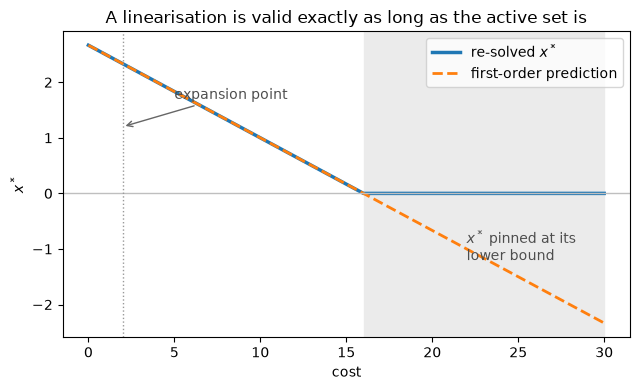

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(grid, exact_x, "-", lw=2.5, label="re-solved $x^*$")
ax.plot(grid, predicted, "--", lw=2, label="first-order prediction")
ax.axhline(0.0, color="0.75", lw=1)
ax.axvline(2.0, color="0.6", lw=1, ls=":")
ax.axvspan(switch, grid[-1], color="0.92", zorder=0)
ax.annotate("expansion point", (2.0, 1.2), xytext=(5.0, 1.7),
            arrowprops=dict(arrowstyle="->", color="0.4"), color="0.3")
ax.annotate("$x^*$ pinned at its\nlower bound", (switch + 6, -1.2), color="0.3")
ax.set_xlabel("cost"); ax.set_ylabel("$x^*$")
ax.set_title("A linearisation is valid exactly as long as the active set is")
ax.legend(loc="upper right"); fig.tight_layout()

Two things worth reading off that figure.

**Below the switch the prediction is not approximate — it is exact.** A quadratic
objective with linear constraints has a solution map that is *affine* in the parameters
while the active set holds, so the first-order term is the whole story and the two curves
lie on top of each other to solver tolerance. The $O(\|\Delta p\|^2)$ error bound is a
worst case, not a fee charged on every step.

**Past the switch it is not approximate either — it is wrong.** At `cost` ≈ 16 the
optimal $x^*$ reaches its lower bound of zero and stays there; the linearisation knows
nothing about that bound and marches on into negative, infeasible territory. It is not
degrading gracefully, it is extrapolating a branch that no longer exists.

That is the honest limit of a first-order sensitivity, and it is why `Sensitivity` carries
`active` and `at_bound`: they are how you check that the branch you linearised on is still
the branch you are standing on.

### Second order

`order=2` also assembles $\partial^2 x^*/\partial p^2$, which lets an outer solver use an
exact Hessian through the solution map instead of a quasi-Newton approximation.

On the blending model it comes back **exactly zero** — and that is the right answer, not a
failure: a quadratic objective with linear constraints has a solution map that is affine
in the parameters, so on a fixed active set $x^*(p)$ has no curvature at all. It is worth
seeing, because it is the cheapest available check that the second-order machinery is
measuring something real rather than returning noise.

In [15]:
s2 = m.sensitivity(order=2)
print("d2x*/dp2 shape :", s2.d2x_dp2.shape, " (n_vars, n_params, n_params)")
print("for x          :\n", s2.d2x_dp2[0], " <- affine solution map, so exactly zero")

d2x*/dp2 shape : (2, 2, 2)  (n_vars, n_params, n_params)
for x          :
 [[0. 0.]
 [0. 0.]]  <- affine solution map, so exactly zero


A curved solution map to contrast: $\min\,(x - p^2)^2$ has $x^*(p) = p^2$, so
$\mathrm{d}x^*/\mathrm{d}p = 2p$ and $\mathrm{d}^2x^*/\mathrm{d}p^2 = 2$ exactly. Here
second order is not decoration — the first-order prediction is visibly wrong at a finite
step, and the second-order one is exact.

In [16]:
def curved(p_value=1.5):
    mc = dm.Model("curved")
    p = mc.parameter("p", value=p_value)
    xc = mc.continuous("x", lb=-50.0, ub=50.0)
    mc.minimize((xc - p * p) ** 2)
    return mc, p, xc


mc, p, xc = curved()
sc = mc.sensitivity(order=2)

print(f"x*           = {float(sc.x_dict['x']):.6f}   (p^2 = {1.5**2:.6f})")
print(f"dx*/dp       = {float(sc.d(xc, p)):.6f}   (2p = {2 * 1.5:.6f})")
print(f"d2x*/dp2     = {float(sc.d2x_dp2[0, 0, 0]):.6f}   (exactly 2)")
print()
target_p = 2.0
print(f"at p = {target_p}:  truth = {target_p**2:.6f}")
print(f"  first order  = {float(sc.predict({p: target_p}, order=1)['x']):.6f}")
print(f"  second order = {float(sc.predict({p: target_p}, order=2)['x']):.6f}")

x*           = 2.250000   (p^2 = 2.250000)
dx*/dp       = 3.000000   (2p = 3.000000)
d2x*/dp2     = 2.000000   (exactly 2)

at p = 2.0:  truth = 4.000000
  first order  = 3.750000
  second order = 4.000000


### `as_layer()` — the same map, as a JAX function

When the model is a *component* of something larger — a training loop, an outer
optimization — you want the solution map as a differentiable callable rather than as
matrices. `as_layer()` hands you $\varphi(p) \mapsto x^*$, differentiable twice, ready for
`jax.grad` / `jax.jit` / `jax.vmap`. This is the decision-focused-learning shape
{cite:p}`Amos2017,Agrawal2019`.

In [17]:
import jax.numpy as jnp

phi = s.as_layer()
p0 = jnp.array([float(cost.value), float(target.value)])

print("phi(p0)                :", np.asarray(phi(p0)))
print("jax.jacobian(phi)(p0)  :\n", np.asarray(jax.jacobian(phi)(p0)))
print("matches s.dx_dp        :", np.allclose(np.asarray(jax.jacobian(phi)(p0)), s.dx_dp, atol=1e-6))

phi(p0)                : [2.33333333 1.66666666]


jax.jacobian(phi)(p0)  :
 [[-0.16666667  0.66666667]
 [ 0.16666667  0.33333333]]


matches s.dx_dp        : True


## 6. The other direction: a derivative *inside* a model

Everything so far differentiates a model from outside. The complementary tool puts an
implicitly defined quantity *into* one: `Model.implicit` defines $v$ by
$g(u, v) = 0$ and supplies the solver with $\mathrm{d}v/\mathrm{d}u = -(\partial
g/\partial v)^{-1}(\partial g/\partial u)$ — the same implicit function theorem, used at
model-build time rather than at post-solve time. Newton runs forward; nothing
differentiates through its iterations.

`dm.argmin` does the same for a whole inner NLP, making a follower's minimizer a block of
an outer model. Both ride on the `CustomCall` contract: the outer model is solved on the
local NLP path only, with no global certificate and no integer variables. The
*Implicit function node* notebook covers the first in full; `dm.argmin`'s docstring covers
the second, including why hand-writing a nonconvex follower's KKT conditions instead is a
relaxation rather than a reformulation.

In [18]:
import jax.numpy as jnp

mi = dm.Model("implicit_demo")
u = mi.continuous("u", lb=0.1, ub=100.0)
v = mi.implicit(lambda U, V: jnp.array([V[0] ** 2 - U[0]]), [u], n_unknowns=1,
                x0=jnp.array([1.0]))
mi.minimize((v[0] - 3.0) ** 2)     # v = sqrt(u); optimum at u = 9

ri = mi.solve()
print(f"status = {ri.status}   u* = {float(ri.x['u']):.6f}   (expected 9)")

No valid dual bound was produced for model 'implicit_demo': the relaxation layer could not bound this objective (status=feasible). The result cannot be certified globally optimal. A nonlinear term with no envelope is the usual cause; an epigraph reformulation (minimize z subject to f(x) <= z) often gives the relaxation something to bound.


status = feasible   u* = 9.000000   (expected 9)


## Summary

| Question | Call |
|---|---|
| Slope of an expression, symbolically | `diff(expr, x)`, `grad(expr, [x, y])` |
| Partials $\partial e/\partial x$, $\partial e/\partial p$ | `compile_expression(expr, m)` + `jax.grad` |
| How the optimum *value* moves | `m.solve(sensitivity=True)` → `result.gradient(p)` |
| How the *solution* moves, and everything else | **`m.sensitivity()`** |
| Raw sIPOPT arrays | `pounce_sensitivity(m, [p])` |
| The solution map as a JAX function | `s.as_layer()`, `dm.argmin_layer(m, [p])` |
| An implicit function *inside* a model | `m.implicit(residual, [u], n_unknowns=k)` |
| An inner NLP inside a model | `dm.argmin(inner, bind={p: outer_expr})` |

Contract for everything in the bottom half of that table: continuous variables only,
scalar parameters only, and the derivatives describe the KKT point the solver returned —
for a nonconvex model, a local one, on the active-set branch recorded in
`s.active` / `s.at_bound`.

Full citation details for the works above are on the [references](../references.md) page.